In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson

# Data Visualization
We are given data of bird counts from 1999-2012. Here we visualize the data in a plot and see that there is no clear pattern. The initial assumption is that this data comes from a Poisson distribution and the mean of this distribution is estimated as:
$$ \lambda(x_i) = \exp(\beta_0 + \beta_1 x_i ), $$
where it is linear on the log scale.

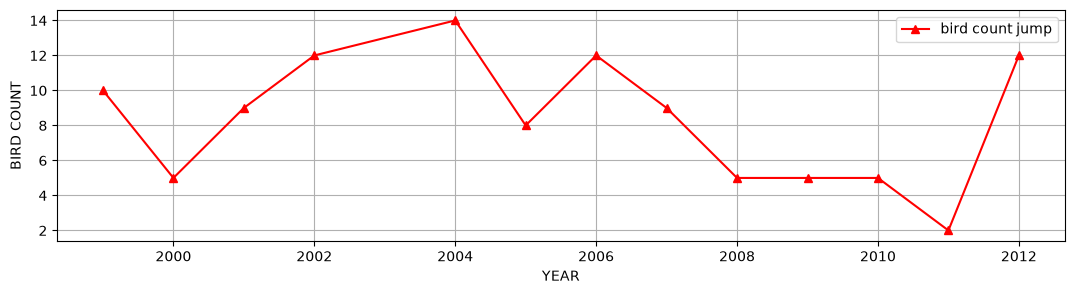

In [2]:
data = pd.read_csv("bird_count.csv")

sorted_idx   = np.argsort(data['yr'])
sorted_year  = np.array(data['yr'][sorted_idx])
sorted_count = np.array(data['count'][sorted_idx])

plt.figure(figsize=(13,3))
plt.plot(sorted_year, sorted_count,'^-', color='red', label='bird count jump')
plt.grid(True)
plt.xlabel('YEAR')
plt.ylabel('BIRD COUNT')
plt.legend()

# Optimization 
The task is another optimization problem, where we want to find the best distribution (or more specifically from a family of Poisson distributions) that best reflects our data. We denote the response (bird counts) as $y$ and the predictor (years) as $x$. Thus, for each data point $i=1,...,n$ the maximum log likelihood function can be obtained by maximizing the following with respect to the coefficients $\beta_0 , \beta_1$:
$$\log ( l(y|\beta_0,\beta_1, x) = \sum_{i=1}^n{-\lambda(x_i)+y_i(\log(\lambda(x_i))-\log(y_i!)}.$$

#### NOTE!: We transform the given predictor values (years) into a range of $[0,1]$ to avoid overflow exceptions in the exponential function. This is done simply by dividing with the maximum of the years.

In [42]:
max_year = max(data['yr'])
reduced_year  = np.array(sorted_year) / max_year

#This is a modified likelihood function where we have ignored the constant term log(y_i!) (with respect to the betas) 
def Poisson_lmlikelihood (betas):
    x = reduced_year
    y = sorted_count
    b0, b1 = betas
    return np.sum( -np.exp( b0 + b1*x ) + y*(b0 + b1*x) )

In [43]:
betas    = minimize( lambda betas: -Poisson_lmlikelihood(betas) , [0.0,0.0]).x
b0, b1   = betas[:2]
#print(b0,b1)

# Optimized Model - Predicting future values
The beta values are used in the estimated point-wise mean value of the Poisson distribution. We can then sample from this distribution and build (95%) confidence intervals. 

In [44]:
def lambda_x (x): return np.exp(b0 + b1*x)
def sample(x, n = 1): return poisson.rvs(mu=lambda_x(x), size=(n, len(x))) 

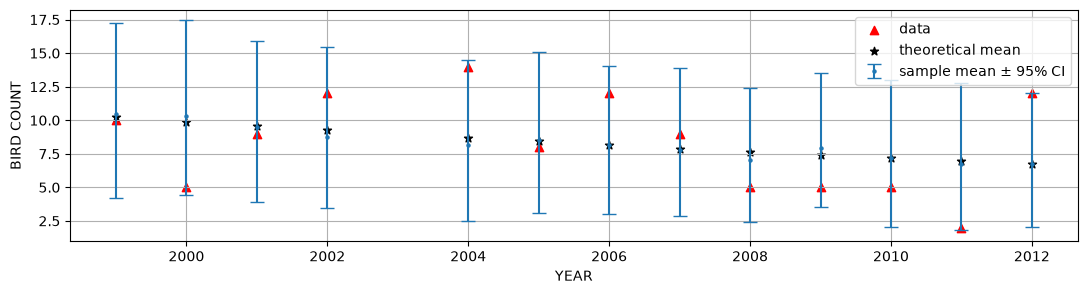

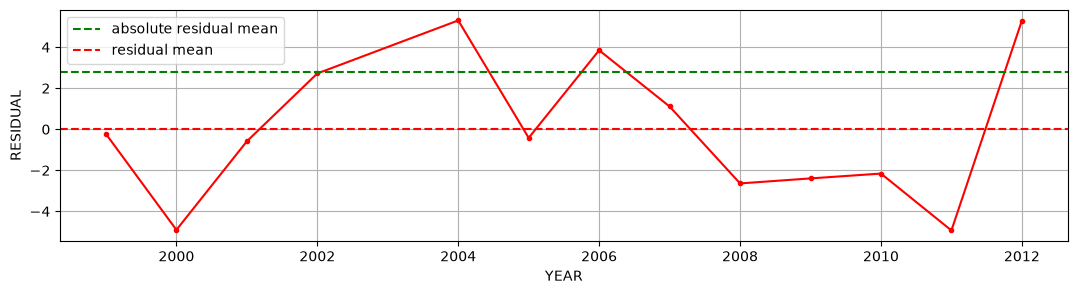

In [45]:
lambda_values  = lambda_x(reduced_year)
sampled_values = sample(reduced_year, n = 50) #shape = (n,len(reduced_year))

#95% confidence interval for Poisson
lower, upper = poisson.interval(0.95, mu=lambda_values)
yerr_lower = lambda_values - lower
yerr_upper = upper - lambda_values

plt.figure(figsize=(13,3))
plt.scatter(sorted_year, sorted_count, color='red', marker='^', label='data')
plt.scatter(sorted_year, lambda_values, color='black', marker ='*', label='theoretical mean')
plt.errorbar(sorted_year, np.mean(sampled_values,axis=0), yerr=[yerr_lower, yerr_upper], fmt='o', capsize=5, markersize=2.2, label='sample mean ± 95% CI')
plt.grid(True)
plt.xlabel('YEAR')
plt.ylabel('BIRD COUNT')
plt.legend()

plt.figure(figsize=(13,3))
plt.plot(sorted_year, sorted_count-lambda_values,'.-', color='red')
plt.axhline(y = np.mean(abs(sorted_count-lambda_values)),color='green',linestyle='--',label='absolute residual mean')
plt.axhline(y = np.mean((sorted_count-lambda_values)),color='red',linestyle='--',label='residual mean')
plt.grid(True)
plt.xlabel('YEAR')
plt.ylabel('RESIDUAL')
plt.legend()

In the first plot, the model gave an overall downward trend. This is not representative of the curve-like form of the given data. This can be explained by the fact that, in the Poisson distribution, the mean (and variance) is equal to $\lambda(x)$ which is an inverse exponential function with a linear exponent(since $\beta_1 < 0$). Thus, if we want future values, we can expect it to decrease exponentially and then converging to zero. A plot of this is shown below.\
It is also interesting to note that the optimization process gave a model with resiudal that has a sample mean of almost zero ($2.5e^{-7}$ to be exact) but with no remarkable performance in residual variance reduction. We also show on the second plot the absolute residual mean which is just the mean of the residual magnitudes (i.e. all postives) which is a more useful tool to judge the model quality. In this case, the quality is reflective of its performance - at least in the training data.

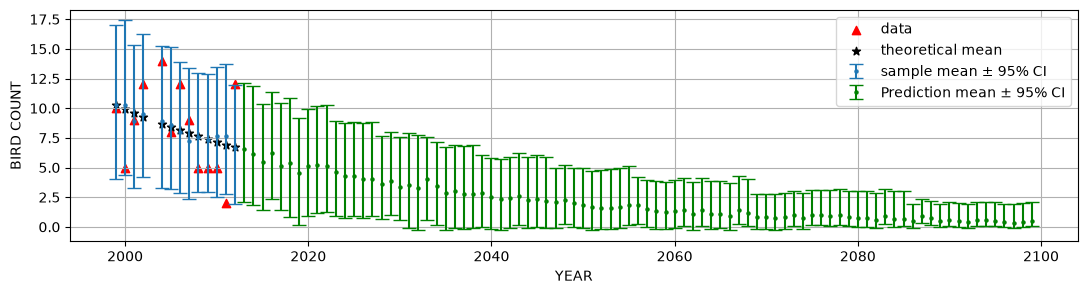

In [37]:
plt.figure(figsize=(13,3))
plt.scatter(sorted_year, sorted_count, color='red', marker='^', label='data')
plt.scatter(sorted_year, lambda_values, color='black', marker ='*', label='theoretical mean')
plt.errorbar(sorted_year, np.mean(sampled_values,axis=0), yerr=[yerr_lower, yerr_upper], fmt='o', capsize=5, markersize=2.2, label='sample mean ± 95% CI')
plt.grid(True)
plt.xlabel('YEAR')
plt.ylabel('BIRD COUNT')
plt.legend()

new_years = range(2013, 2100)
new_reduced = np.array([year / max_year for year in new_years])
new_lambdas = lambda_x(new_reduced)
new_samples = sample(new_reduced, n = 50) #shape = (n,len(reduced_year))

newlower, newupper = poisson.interval(0.95, mu=new_lambdas)
new_yerr_lower = new_lambdas - newlower
new_yerr_upper = newupper - new_lambdas

plt.errorbar(new_years, np.mean(new_samples, axis=0), yerr=[new_yerr_lower, new_yerr_upper], fmt='o', markersize=2.2, capsize=5, color='green', label='Prediction mean ± 95% CI')
plt.legend()